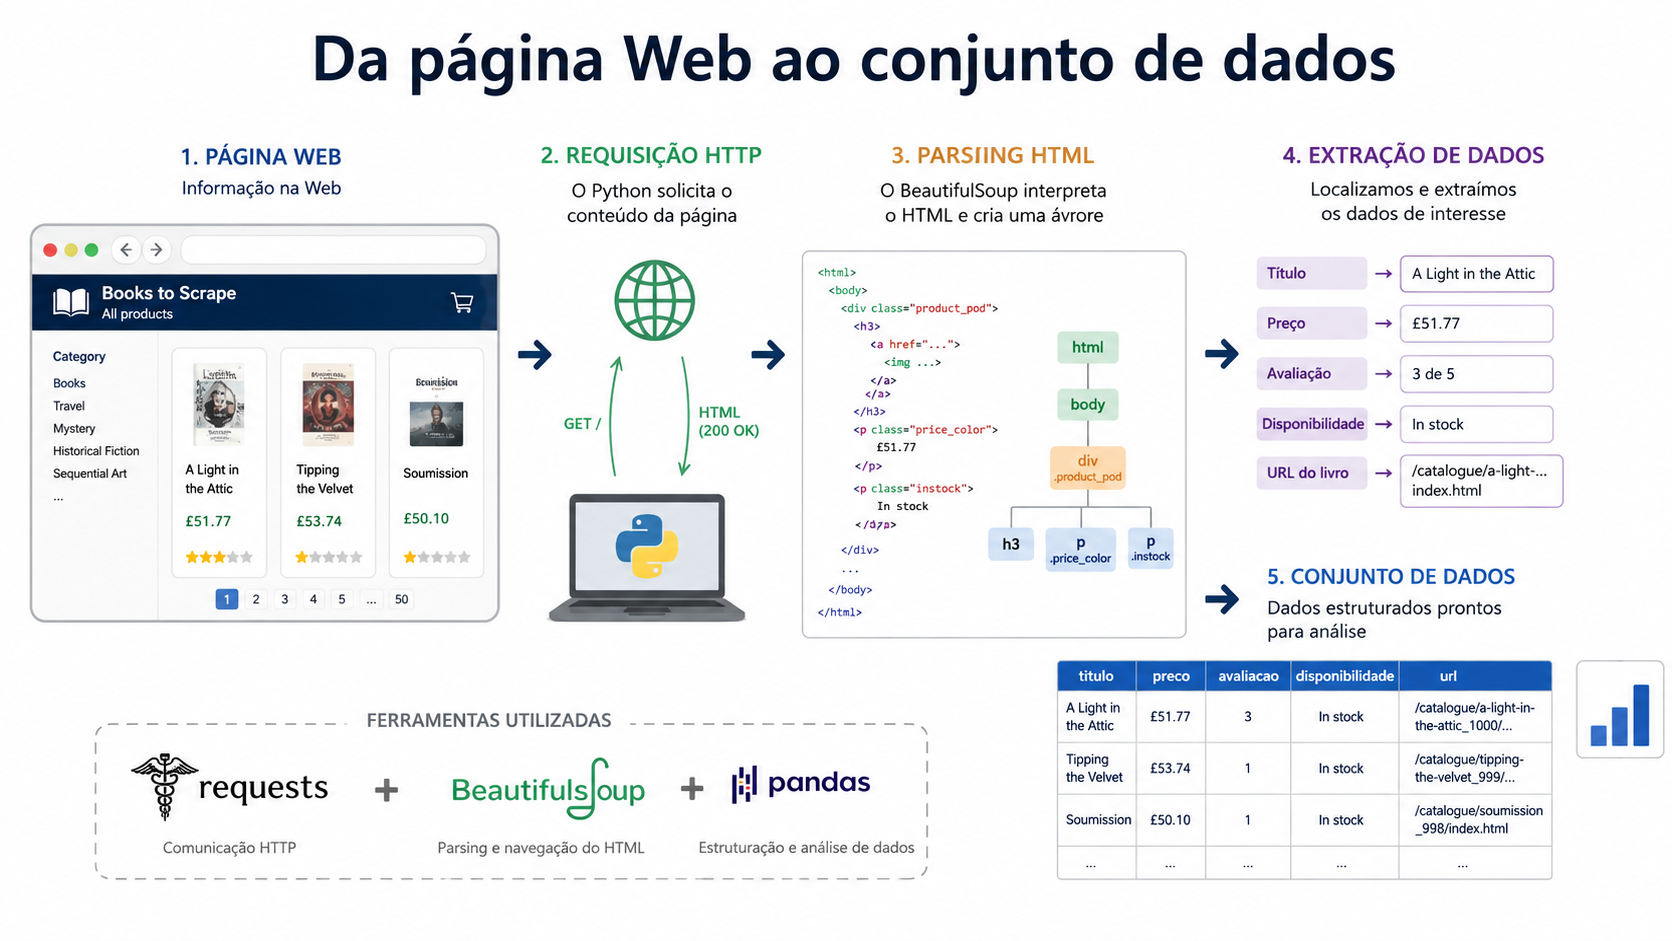

Nesta aula, vamos compreender como informações publicadas em páginas Web podem ser **requisitadas, interpretadas, localizadas, extraídas e estruturadas** com Python.

## 1. O que é Web Scraping?

**Web Scraping** é o processo automatizado de coleta de informações disponíveis em páginas Web.

Em termos computacionais, o processo envolve três operações principais:

1. **Aquisição:** obtenção do conteúdo da página por meio de uma requisição HTTP;
2. **Parsing:** interpretação da estrutura do documento HTML;
3. **Extração:** localização e transformação dos elementos de interesse em dados utilizáveis.

Um fluxo típico pode ser representado como:

```text
URL → Requisição HTTP → HTML → Parser → Elementos → Dados estruturados
```

### Exemplos de aplicação

- monitoramento de preços;
- coleta de notícias e documentos;
- criação de bases para análise de mercado;
- mineração de dados públicos;
- acompanhamento de indicadores;
- construção de datasets para pesquisa.

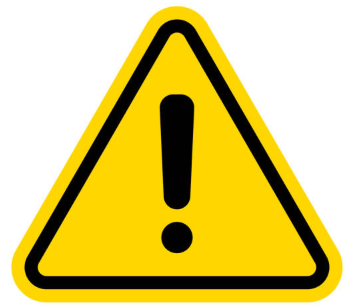
# Atenção - Evite práticas ilegais e antiéticas
#### Respeite as regras contidas do documento **Robots.txt**. 

A disponibilidade pública de uma página não implica autorização irrestrita para coleta automatizada. Termos de uso, limites de requisição, privacidade e legislação aplicável devem ser considerados.

O scraper deve seguir as regras estabelecidas no arquivo **robots.txt** do site e respeitar os termos de uso para evitar práticas ilegais ou antiéticas.

# 2. Fundamentos de HTML

## HTML: HyperText Markup Language

**HTML** é a linguagem de marcação utilizada para representar a estrutura de uma página Web.

- Geralmente contém três componentes
    - Tag de abertura;
    - Conteúdo;
    - Tag de fechamento
    
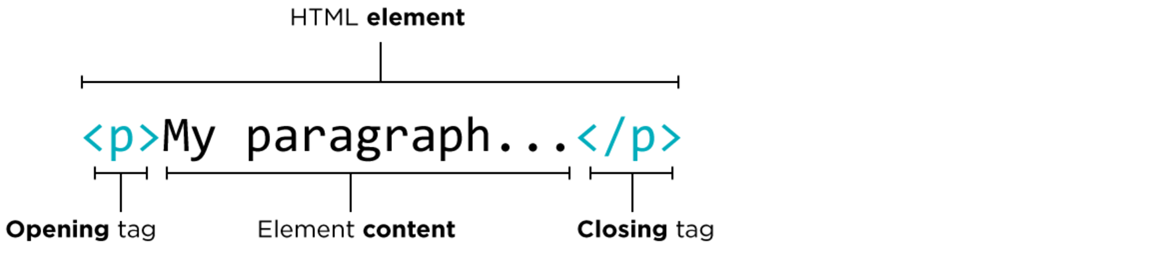

Tags de abertura também podem conter atributos:

```html
<tag atributo="valor">conteúdo</tag>
```

Exemplo:

```html
<p class="preco">R$ 89,90</p>
```

Neste elemento:

| Componente | Valor |
|---|---|
| Tag | `p` |
| Atributo | `class` |
| Valor do atributo | `preco` |
| Conteúdo textual | `R$ 89,90` |

Em tarefas de Web Scraping, esses componentes funcionam como **pistas para localizar a informação desejada**.

## Estrutura básica de um documento HTML

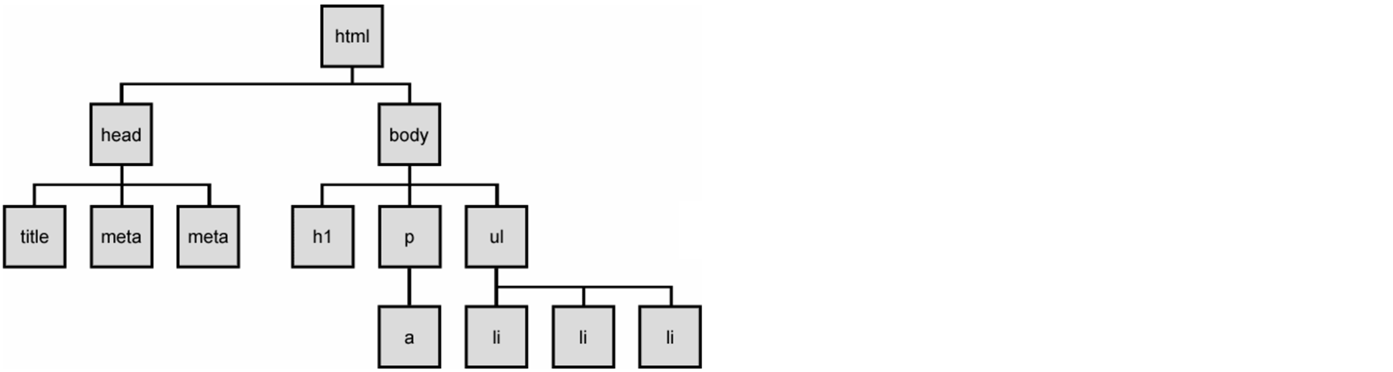

Exemplo codificado:

```html
<!DOCTYPE html>
<html>
    <head>
        <title>Minha página</title>
    </head>

    <body>
        <h1>Título principal</h1>
        <p>Um parágrafo.</p>
        <a href="https://exemplo.com">Um link</a>
    </body>
</html>
```

A estrutura HTML possui natureza **hierárquica**. Por isso, ela pode ser interpretada como uma árvore:

```text
html
├── head
│   └── title
└── body
    ├── h1
    ├── p
    └── a
```

Essa organização será importante quando utilizarmos `BeautifulSoup`.

## Algumas tags HTML frequentes

| Tag | Função típica |
|---|---|
| `<html>` | elemento raiz do documento |
| `<head>` | metadados e configurações |
| `<title>` | título da página |
| `<body>` | conteúdo visível principal |
| `<h1>` ... `<h6>` | títulos e subtítulos |
| `<p>` | parágrafo |
| `<a>` | hiperlink |
| `<img>` | imagem |
| `<div>` | agrupamento genérico |
| `<span>` | agrupamento inline |
| `<ul>` / `<ol>` | listas |
| `<li>` | item de lista |
| `<table>` | tabela |
| `<article>` | conteúdo independente |
| `<nav>` | navegação |

# 3. HTTP: comunicação entre cliente e servidor

**HTTP (Hypertext Transfer Protocol)** é o protocolo utilizado na comunicação entre clientes e servidores Web.

Quando digitamos uma URL no navegador, ocorre, de forma simplificada:

```text
Cliente                          Servidor
   │                                │
   │ -------- HTTP GET -----------> │
   │                                │
   │ <----- HTTP Response --------- │
   │        status + conteúdo       │
```

Em Python, a biblioteca `requests` pode assumir o papel do cliente.

## Métodos HTTP

Alguns métodos HTTP importantes:

| Método | Finalidade geral |
|---|---|
| `GET` | solicitar um recurso |
| `POST` | enviar dados para processamento |
| `PUT` | substituir ou atualizar um recurso |
| `PATCH` | atualizar parcialmente um recurso |
| `DELETE` | solicitar remoção de um recurso |

Nesta aula utilizaremos principalmente **GET**, pois nosso objetivo é solicitar páginas HTML.

## Códigos de status HTTP

Uma resposta HTTP possui um código de status.

| Faixa | Categoria | Exemplo |
|---|---|---|
| `1xx` | Informacional | processamento em andamento |
| `2xx` | Sucesso | `200 OK` |
| `3xx` | Redirecionamento | `301 Moved Permanently` |
| `4xx` | Erro do cliente | `404 Not Found` |
| `5xx` | Erro do servidor | `500 Internal Server Error` |

Para Web Scraping, um `200` normalmente indica que a requisição foi atendida com sucesso.

# 4. Web Scraping não é API

É importante diferenciar duas formas de obter dados de um sistema Web.

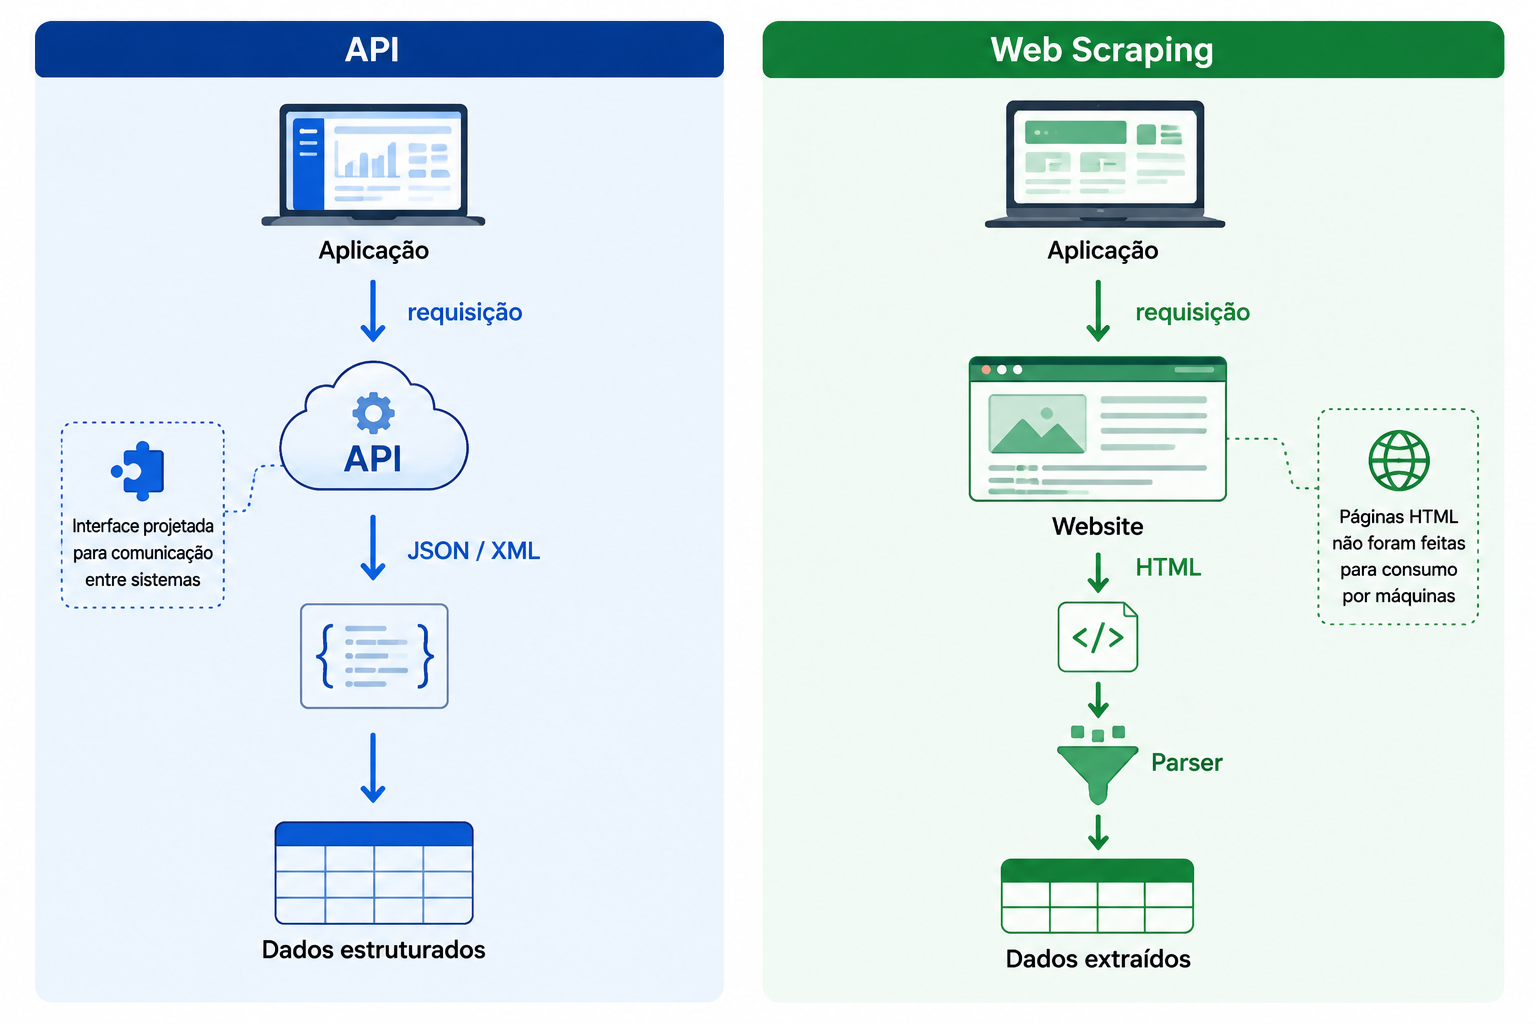

Em tarefas de Web Scraping, os dados precisam ser identificados dentro da estrutura destinada originalmente à apresentação da página.

## Páginas estáticas e páginas dinâmicas

Um ponto fundamental:

```python
requests.get(url)
```

obtém o conteúdo retornado pelo servidor na resposta HTTP.

Entretanto, alguns websites carregam parte dos dados **posteriormente com JavaScript**.

```text
HTML inicial
    │
    ├── conteúdo disponível imediatamente
    │
    └── JavaScript
           │
           └── novas requisições / conteúdo dinâmico
```

Nesses casos, o conteúdo visível no navegador pode não estar presente no HTML obtido diretamente com `requests`.

Ferramentas como **Selenium** e **Playwright** podem ser utilizadas em cenários mais complexos, mas não são necessárias para a prática desta aula.

# 5. Preparando o ambiente

Nesta aula utilizaremos:

- `requests`: comunicação HTTP;
- `BeautifulSoup`: parsing e navegação HTML;
- `re`: expressões regulares;
- `pandas`: estruturação dos dados;
- `urllib.parse`: construção segura de URLs.

In [2]:
# Execute somente se as bibliotecas ainda não estiverem instaladas.
%pip install requests beautifulsoup4 pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
import re
import requests
import pandas as pd

from bs4 import BeautifulSoup # biblioteca para webscraping
from urllib.parse import urljoin #juntar url

# 6. Primeiro contato com BeautifulSoup: HTML controlado

Antes de trabalhar com um website real, utilizaremos um pequeno documento HTML criado especificamente para a aula.

Essa estratégia permite aprender os comandos do `BeautifulSoup` sem a complexidade adicional de páginas reais.

In [4]:
html = '''
<html>
    <head>
        <title>Livraria Exemplo</title>
    </head>

    <body>
        <h1>Catálogo de livros</h1>

        <div class="produto" data-categoria="programacao">
            <h2>Python para Dados</h2>
            <p class="preco">R$ 89,90</p>
            <p class="estoque">Disponível</p>
            <a href="/python">Detalhes</a>
        </div>

        <div class="produto" data-categoria="ia">
            <h2>Machine Learning</h2>
            <p class="preco">R$ 120,00</p>
            <p class="estoque">Disponível</p>
            <a href="/machine-learning">Detalhes</a>
        </div>
    </body>
</html>
'''

## Realizando o parsing

O **parsing** transforma o texto HTML em uma estrutura que pode ser navegada programaticamente.

In [5]:
soup = BeautifulSoup(html, 'html.parser')

In [6]:
print(soup.prettify())

<html>
 <head>
  <title>
   Livraria Exemplo
  </title>
 </head>
 <body>
  <h1>
   Catálogo de livros
  </h1>
  <div class="produto" data-categoria="programacao">
   <h2>
    Python para Dados
   </h2>
   <p class="preco">
    R$ 89,90
   </p>
   <p class="estoque">
    Disponível
   </p>
   <a href="/python">
    Detalhes
   </a>
  </div>
  <div class="produto" data-categoria="ia">
   <h2>
    Machine Learning
   </h2>
   <p class="preco">
    R$ 120,00
   </p>
   <p class="estoque">
    Disponível
   </p>
   <a href="/machine-learning">
    Detalhes
   </a>
  </div>
 </body>
</html>



## 6.1 `find()`: localizar a primeira ocorrência

O método `find()` retorna o **primeiro elemento** que corresponde ao critério informado.

In [7]:
soup.find("h2") # retorna o primeiro elemento h2 encontrado

<h2>Python para Dados</h2>

In [8]:
titulo = soup.find("h1")
print(titulo.text) # retorna o texto do elemento h1, mais 

Catálogo de livros


### A propriedade `.text`

O objeto retornado pelo `BeautifulSoup` contém a tag completa.

```html
<h1>Catálogo de livros</h1>
```

Quando queremos apenas seu conteúdo textual:

```python
elemento.text
```

ou, preferencialmente quando há espaços e quebras de linha:

```python
elemento.get_text(strip=True)
```

In [9]:
titulo.get_text(strip=True) # retorna o texto do elemento h1, sem espaços em branco

'Catálogo de livros'

## 6.2 `find_all()`: localizar todas as ocorrências

Enquanto `find()` retorna uma ocorrência, `find_all()` retorna uma coleção de elementos.

varios elementos

In [10]:
produtos=soup.find_all("div") # retorna todos os elementos div encontrados
produtos

[<div class="produto" data-categoria="programacao">
 <h2>Python para Dados</h2>
 <p class="preco">R$ 89,90</p>
 <p class="estoque">Disponível</p>
 <a href="/python">Detalhes</a>
 </div>,
 <div class="produto" data-categoria="ia">
 <h2>Machine Learning</h2>
 <p class="preco">R$ 120,00</p>
 <p class="estoque">Disponível</p>
 <a href="/machine-learning">Detalhes</a>
 </div>]

In [11]:
print("qtd produtos", len(produtos)) # retorna a quantidade de elementos div encontrados

qtd produtos 2


In [12]:
len(produtos) #lista com comprimento 2, pois existem 2 elementos div no html, lista de produtos

2

In [13]:
produtos[1]

<div class="produto" data-categoria="ia">
<h2>Machine Learning</h2>
<p class="preco">R$ 120,00</p>
<p class="estoque">Disponível</p>
<a href="/machine-learning">Detalhes</a>
</div>

## 6.3 Localizando elementos por classe

O atributo HTML `class` é muito utilizado para identificar grupos de elementos.

No `BeautifulSoup`, podemos utilizar:

```python
class_="nome_da_classe"
```

O caractere `_` é necessário porque `class` é uma palavra reservada da linguagem Python.

In [14]:
precos =soup.find_all("div",class_="produto") # retorna todos os elementos p com a classe preco (div com a classe produto)
for i in precos:
    print(i.text) #retorna o texto de cada elemento p com a classe preco


Python para Dados
R$ 89,90
Disponível
Detalhes


Machine Learning
R$ 120,00
Disponível
Detalhes



## 6.4 Localizando elementos por atributos

Também podemos pesquisar elementos por outros atributos.

In [15]:
produto_ia =soup.find("div", attrs = {"data-categoria: ia"})
produto_ia

## 6.5 Extraindo atributos

Considere:

```html
<a href="/python">Detalhes</a>
```

O texto é `Detalhes`, enquanto o destino do link está no atributo `href`.

In [20]:
link=soup.find("a")
print(link)
print("texto visível no link: ", link.get_text(strip=True))
print("link: ",link("href"))

<a href="/python">Detalhes</a>
texto visível no link:  Detalhes
link:  []


Uma alternativa mais segura para atributos opcionais é utilizar `.get()`:

In [23]:
link.get("href") #href que contém o link para a página do produto

'/python'

## 6.6 Localização por texto

Também é possível localizar elementos por conteúdo textual.

In [24]:
soup.find("h2", string="Machine Learning") # retorna o elemento h2 com o texto "Machine Learning"

<h2>Machine Learning</h2>

Quando não conhecemos exatamente o texto, expressões regulares podem ser úteis.

In [25]:
soup.find("h2", string=re.compile("machine",re.IGNORECASE)) # retorna o elemento h2 com o texto "Machine Learning", ignorando maiúsculas e minúsculas, como um like em sql, usando regex

<h2>Machine Learning</h2>

In [26]:
soup.find_all("a") # retorna todos os elementos a encontrados

[<a href="/python">Detalhes</a>, <a href="/machine-learning">Detalhes</a>]

# 7. Navegando pela árvore HTML

Como o HTML possui estrutura hierárquica, um elemento pode ter:

- **pai** (`parent`);
- **filhos** (`children` ou `contents`);
- elementos anteriores e posteriores.

Considere o primeiro produto:

In [28]:
#pai e filho (tag anterior e tag posterior)
primeiro_produto =soup.find("div",class_="produto") #tras o primeiro elemento div com a classe produto
primeiro_produto

<div class="produto" data-categoria="programacao">
<h2>Python para Dados</h2>
<p class="preco">R$ 89,90</p>
<p class="estoque">Disponível</p>
<a href="/python">Detalhes</a>
</div>

In [29]:
primeiro_produto.parent # retorna o elemento pai do primeiro elemento div com a classe produto, que é o elemento body

<body>
<h1>Catálogo de livros</h1>
<div class="produto" data-categoria="programacao">
<h2>Python para Dados</h2>
<p class="preco">R$ 89,90</p>
<p class="estoque">Disponível</p>
<a href="/python">Detalhes</a>
</div>
<div class="produto" data-categoria="ia">
<h2>Machine Learning</h2>
<p class="preco">R$ 120,00</p>
<p class="estoque">Disponível</p>
<a href="/machine-learning">Detalhes</a>
</div>
</body>

In [31]:
primeiro_produto.parent.name # retorna o nome do elemento pai do primeiro elemento div com a classe produto, que é body, pois está a esquerda do elemento div com a classe produto, que é o elemento body

'body'

In [32]:
primeiro_produto.contents

['\n',
 <h2>Python para Dados</h2>,
 '\n',
 <p class="preco">R$ 89,90</p>,
 '\n',
 <p class="estoque">Disponível</p>,
 '\n',
 <a href="/python">Detalhes</a>,
 '\n']

In [35]:
primeiro_produto.contents[0] # retorna o primeiro elemento filho do primeiro elemento div com a classe produto, que é o elemento h2
primeiro_produto.contents[1] # retorna o segundo elemento filho do primeiro elemento div com a classe produto, que é o elemento p com a classe preco

<h2>Python para Dados</h2>

In [37]:
list(primeiro_produto.children) # retorna uma lista com os elementos filhos do primeiro elemento div com a classe produto, que são o elemento h2 e o elemento p com a classe preco, fica mais compreeensível, pois o conteúdo do elemento div com a classe produto é uma lista de elementos filhos, que são o elemento h2 e o elemento p com a classe preco

['\n',
 <h2>Python para Dados</h2>,
 '\n',
 <p class="preco">R$ 89,90</p>,
 '\n',
 <p class="estoque">Disponível</p>,
 '\n',
 <a href="/python">Detalhes</a>,
 '\n']

In [39]:
for filho in primeiro_produto.children:
    print(filho.text) # retorna cada elemento filho do primeiro elemento div com a classe produto, que são o elemento h2 e o elemento p com a classe preco, somente o texto



Python para Dados


R$ 89,90


Disponível


Detalhes




> **Observação:** `children` e `contents` acessam os filhos imediatos, incluindo tags e nós de texto. A diferença é que contents retorna uma lista, enquanto children fornece um iterador.

# 8. Seletores CSS

O `BeautifulSoup` também permite utilizar seletores CSS.

**CSS (Cascading Style Sheets)** é a linguagem utilizada para definir a **aparência e o layout dos elementos HTML** de uma página, como cores, fontes, tamanhos e posicionamento.

Um seletor **CSS** é uma expressão utilizada para identificar quais **elementos HTML receberão determinado estilo**. Em tarefas de Web Scraping, podemos reutilizar esses seletores para localizar elementos na página.

Essa abordagem é útil porque o mesmo raciocínio empregado no inspetor do navegador pode ser utilizado no Python.

Exemplos:

```css
div.produto
div.produto h2
p.preco
a
```

In [40]:
soup.select("div.produto") # retorna todos os elementos div com a classe produto, usando CSS selector

[<div class="produto" data-categoria="programacao">
 <h2>Python para Dados</h2>
 <p class="preco">R$ 89,90</p>
 <p class="estoque">Disponível</p>
 <a href="/python">Detalhes</a>
 </div>,
 <div class="produto" data-categoria="ia">
 <h2>Machine Learning</h2>
 <p class="preco">R$ 120,00</p>
 <p class="estoque">Disponível</p>
 <a href="/machine-learning">Detalhes</a>
 </div>]

In [41]:
soup.select("div.produto h2") # retorna todos os elementos h2 que são filhos de elementos div com a classe produto, usando CSS selector

[<h2>Python para Dados</h2>, <h2>Machine Learning</h2>]

In [42]:
soup.select_one("div.produto h2") # retorna o primeiro elemento h2 que é filho de um elemento div com a classe produto, usando CSS selector

<h2>Python para Dados</h2>

In [44]:
soup.select("div.produto h2")[-1] # retorna o último elemento h2 que é filho de um elemento div com a classe produto, usando CSS selector
soup.select("div.produto h2")[0] # retorna o primeiro elemento h2 que é filho de um elemento div com a classe produto, usando CSS selector

<h2>Python para Dados</h2>

In [46]:
titulos = soup.select("div.produto h2")
for i in titulos:
    print(i.get_text(strip=True)) # retorna o texto de cada elemento h2 que é filho de um elemento div com a classe produto, usando CSS selector

Python para Dados
Machine Learning


In [48]:
[i.get_text(strip=True) for i in soup.select("div.produto h2")] # retorna o texto de cada elemento h2 que é filho de um elemento div com a classe produto, usando CSS selector

['Python para Dados', 'Machine Learning']

## `find()` ou `select()`?

As duas abordagens podem resolver problemas semelhantes.

| BeautifulSoup | CSS Selector |
|---|---|
| `find("h2")` | `select_one("h2")` |
| `find_all("h2")` | `select("h2")` |
| `find_all("div", class_="produto")` | `select("div.produto")` |

Não existe necessidade de escolher uma única abordagem. O importante é utilizar seletores claros e suficientemente estáveis.

# 9. Mão na massa: um website real

Agora aplicaremos os conceitos em um ambiente criado especificamente para treinamento de Web Scraping:

**Books to Scrape**  
`https://books.toscrape.com/`

O site contém livros fictícios, categorias, preços, avaliações e paginação. Isso permite trabalhar com uma página real, mas com estrutura relativamente previsível.

> O próprio site informa que foi criado para demonstração de Web Scraping.

## 9.1 Realizando a requisição HTTP

Observe a separação de responsabilidades:

```text
requests      → obtém a resposta HTTP
BeautifulSoup → interpreta o HTML
pandas        → estrutura os dados
```

In [51]:
url = "https://books.toscrape.com/" # -> página não existe, para testar o código de erro 404 (página não encontrada)
response = requests.get(url,timeout=10) # definindo um tempo limite de 10 segundos para a requisição, caso o site não responda nesse tempo, será gerado um erro

print("Status:", response.status_code) # retorna o status da requisição, 200 significa que a requisição foi bem sucedida, se conseguiu acessar a página, caso contrário, retornará um código de erro, como 404 (página não encontrada) ou 500 (erro interno do servidor)


Status: 200


## 9.2 `response.text` versus `response.content`

- `response.text`: conteúdo convertido para `str`;
- `response.content`: conteúdo bruto em `bytes`.

Para analisar HTML com `BeautifulSoup`, `response.text` é suficiente na maioria dos exemplos introdutórios.

<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
        <meta name="created" content="24th Jun 2016 09:29" />
        <meta name="description" content="" />
        <meta name="viewport" content="width=device-width" />
        <meta name="robots" content="NOARCHIVE,NOCACHE" />

        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
        <!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->

        
            <link rel="shortcut icon" href="static/oscar/favicon.

Evite imprimir todo o HTML de páginas extensas. Mostrar apenas uma amostra facilita a inspeção.

## 9.3 Interpretando o HTML com BeautifulSoup

<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!-->
<html class="no-js" lang="en-us">
 <!--<![endif]-->
 <head>
  <title>
   All products | Books to Scrape - Sandbox
  </title>
  <meta content="text/html; charset=utf-8" http-equiv="content-type"/>
  <meta content="24th Jun 2016 09:29" name="created"/>
  <meta content="" name="description"/>
  <meta content="width=device-width" name="viewport"/>
  <meta content="NOARCHIVE,NOCACHE" name="robots"/>
  <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
  <!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->
  <link href="static/oscar/favicon.ico" rel="shortcut icon"/>
  <link href="static/oscar/css/styles.css" rel="stylesheet" type="tex

## 9.4 Extraindo informações simples

Título da página: All products | Books to Scrape - Sandbox


# 10. Identificando a unidade de análise

Ao inspecionar a página, observamos que cada livro está contido em um elemento:

```html
<article class="product_pod">
    ...
</article>
```

Isso é importante porque define nossa **unidade de análise**:

> uma ocorrência de `article.product_pod` corresponde a um livro.

<article class="product_pod">
 <div class="image_container">
  <a href="catalogue/a-light-in-the-attic_1000/index.html">
   <img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/>
  </a>
 </div>
 <p class="star-rating Three">
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
 </p>
 <h3>
  <a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">
   A Light in the ...
  </a>
 </h3>
 <div class="product_price">
  <p class="price_color">
   Â£51.77
  </p>
  <p class="instock availability">
   <i class="icon-ok">
   </i>
   In stock
  </p>
  <form>
   <button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">
    Add to basket
   </button>
  </form>
 </div>
</article>



## 10.1 Extraindo o título de um livro

O título está armazenado no atributo `title` do link interno ao elemento `<h3>`.

A Light in the Attic


## 10.2 Extraindo o preço

Â£51.77


## 10.3 Extraindo a disponibilidade

In stock


## 10.4 Extraindo o link

O link apresentado no HTML é relativo. Para obter uma URL completa, utilizaremos `urljoin()`.

href: catalogue/a-light-in-the-attic_1000/index.html
URL completa: https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html


## 10.5 Extraindo a avaliação

A avaliação está codificada por meio de classes HTML.

Um elemento pode aparecer, por exemplo, como:

```html
<p class="star-rating Three">
```

Nesse caso, uma das classes indica a quantidade de estrelas.

['star-rating', 'Three']


## 10.6 Reunindo os atributos de um único livro

{'titulo': 'A Light in the Attic',
 'preco': 'Â£51.77',
 'avaliacao': <p class="star-rating Three">
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 </p>,
 'disponibilidade': 'In stock',
 'url': 'https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html'}

# 11. De um elemento para vários registros

Agora substituímos:

```python
find(...)
```

por:

```python
find_all(...)
```

para localizar todos os livros da página.

Quantidade encontrada: 20


## Extraindo todos os livros da página

A estratégia será:

```text
para cada livro:
    localizar título
    localizar preço
    localizar avaliação
    localizar disponibilidade
    localizar URL
    armazenar registro
```

In [ ]:
dados = []

mapa_estrelas = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

for livro in livros:
    link_titulo = livro.find("h3").find("a")

    titulo = link_titulo.get("title")
    preco = livro.find("p", class_="price_color").get_text(strip=True)
    disponibilidade = livro.find(
        "p",
        class_="instock availability"
    ).get_text(strip=True)

    href = link_titulo.get("href")
    url_livro = urljoin(url, href)

    rating_tag = livro.find("p", class_="star-rating")
    classes = rating_tag.get("class", [])

    avaliacao = next(
        (mapa_estrelas[c] for c in classes if c in mapa_estrelas),
        None
    )

    dados.append({
        "titulo": titulo,
        "preco": preco,
        "avaliacao": avaliacao,
        "disponibilidade": disponibilidade,
        "url": url_livro
    })

len(dados)

20

# 12. Transformando os dados em um DataFrame

A partir deste ponto deixamos de trabalhar apenas com elementos HTML e passamos a trabalhar com uma estrutura típica de análise de dados.

In [ ]:
df = pd.DataFrame(dados)
df

,titulo,preco,avaliacao,disponibilidade,url
0,A Light in the Attic,Â£51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,Â£53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,Â£50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,Â£47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,Â£54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...
5,The Requiem Red,Â£22.65,1,In stock,https://books.toscrape.com/catalogue/the-requi...
6,The Dirty Little Secrets of Getting Your Dream...,Â£33.34,4,In stock,https://books.toscrape.com/catalogue/the-dirty...
7,The Coming Woman: A Novel Based on the Life of...,Â£17.93,3,In stock,https://books.toscrape.com/catalogue/the-comin...
8,The Boys in the Boat: Nine Americans and Their...,Â£22.60,4,In stock,https://books.toscrape.com/catalogue/the-boys-...
9,The Black Maria,Â£52.15,1,In stock,https://books.toscrape.com/catalogue/the-black...


(20, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   titulo           20 non-null     object
 1   preco            20 non-null     object
 2   avaliacao        20 non-null     int64 
 3   disponibilidade  20 non-null     object
 4   url              20 non-null     object
dtypes: int64(1), object(4)
memory usage: 932.0+ bytes


## 12.1 Limpeza básica do preço

O preço foi extraído como texto, por exemplo:

```text
£51.77
```

Para análise numérica, removeremos o símbolo monetário e converteremos a coluna para `float`.

,titulo,preco,avaliacao,disponibilidade,url
0,A Light in the Attic,51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...
5,The Requiem Red,22.65,1,In stock,https://books.toscrape.com/catalogue/the-requi...
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4,In stock,https://books.toscrape.com/catalogue/the-dirty...
7,The Coming Woman: A Novel Based on the Life of...,17.93,3,In stock,https://books.toscrape.com/catalogue/the-comin...
8,The Boys in the Boat: Nine Americans and Their...,22.60,4,In stock,https://books.toscrape.com/catalogue/the-boys-...
9,The Black Maria,52.15,1,In stock,https://books.toscrape.com/catalogue/the-black...


Agora já podemos realizar operações analíticas simples.

count    20.000000
mean     38.048500
std      15.135231
min      13.990000
25%      22.637500
50%      41.380000
75%      51.865000
max      57.250000
Name: preco, dtype: float64

avaliacao
1    6
2    3
3    3
4    4
5    4
Name: count, dtype: int64

# 13. Melhorando o código: criando uma função

Quando uma operação será repetida, encapsular a lógica em uma função melhora:

- legibilidade;
- reutilização;
- manutenção;
- testabilidade.

In [ ]:
def extrair_livros(soup, url_base):
    mapa_estrelas = {
        "One": 1,
        "Two": 2,
        "Three": 3,
        "Four": 4,
        "Five": 5
    }

    registros = []

    for livro in soup.find_all("article", class_="product_pod"):
        link_titulo = livro.find("h3").find("a")

        titulo = link_titulo.get("title")
        preco = livro.find("p", class_="price_color").get_text(strip=True)
        disponibilidade = livro.find(
            "p",
            class_="instock availability"
        ).get_text(strip=True)

        href = link_titulo.get("href")
        url_livro = urljoin(url_base, href)

        rating_tag = livro.find("p", class_="star-rating")
        classes = rating_tag.get("class", [])

        avaliacao = next(
            (mapa_estrelas[c] for c in classes if c in mapa_estrelas),
            None
        )

        registros.append({
            "titulo": titulo,
            "preco": preco,
            "avaliacao": avaliacao,
            "disponibilidade": disponibilidade,
            "url": url_livro
        })

    return registros

,titulo,preco,avaliacao,disponibilidade,url
0,A Light in the Attic,Â£51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,Â£53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,Â£50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,Â£47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,Â£54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...


# 14. Tratamento básico de erros

Em aplicações reais, requisições podem falhar por:

- indisponibilidade do servidor;
- timeout;
- problemas de conexão;
- códigos HTTP de erro;
- alterações na estrutura da página.

Evite utilizar `except:` de forma genérica. Capture exceções compatíveis com o problema que está sendo tratado.

In [ ]:
def obter_soup(url, timeout=10):
    try:
        response = requests.get(url, timeout=timeout)
        response.raise_for_status()
        return BeautifulSoup(response.text, "html.parser")

    except requests.exceptions.RequestException as erro:
        print(f"Falha ao acessar {url}: {erro}")
        return None

In [ ]:
soup_teste = obter_soup("https://books.toscrape.com/")

if soup_teste is not None:
    print(soup_teste.title.get_text(strip=True))

All products | Books to Scrape - Sandbox


# 15. Introdução à paginação

A primeira página contém apenas uma parte do catálogo.

No rodapé da página existe um link para a próxima página.

A lógica de paginação pode ser representada como:

```text
Página 1
   │
   └── next ──► Página 2
                    │
                    └── next ──► Página 3
                                      │
                                      └── ...
```

Uma estratégia robusta é seguir o link `next` até que ele deixe de existir.

href: catalogue/page-2.html
URL completa: https://books.toscrape.com/catalogue/page-2.html


## Função para percorrer múltiplas páginas

A célula abaixo demonstra o padrão. Para não realizar dezenas de requisições acidentalmente durante a aula, usamos o parâmetro `max_paginas`.

In [ ]:
def coletar_catalogo(url_inicial, max_paginas=3):
    url_atual = url_inicial
    todos_os_registros = []
    pagina = 1

    while url_atual and pagina <= max_paginas:
        print(f"Coletando página {pagina}: {url_atual}")

        soup_pagina = obter_soup(url_atual)

        if soup_pagina is None:
            break

        todos_os_registros.extend(
            extrair_livros(soup_pagina, url_atual)
        )

        link_proxima = soup_pagina.select_one("li.next a")

        if link_proxima is None:
            url_atual = None
        else:
            url_atual = urljoin(
                url_atual,
                link_proxima.get("href")
            )

        pagina += 1

    return pd.DataFrame(todos_os_registros)

In [ ]:
# Exemplo: coletar somente as três primeiras páginas.
# Altere max_paginas apenas quando desejar ampliar a coleta.

df_catalogo = coletar_catalogo(
    "https://books.toscrape.com/",
    max_paginas=3
)

df_catalogo.shape

Coletando página 1: https://books.toscrape.com/
Coletando página 2: https://books.toscrape.com/catalogue/page-2.html
Coletando página 3: https://books.toscrape.com/catalogue/page-3.html


(60, 5)

,titulo,preco,avaliacao,disponibilidade,url
0,A Light in the Attic,Â£51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,Â£53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,Â£50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,Â£47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,Â£54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...
5,The Requiem Red,Â£22.65,1,In stock,https://books.toscrape.com/catalogue/the-requi...
6,The Dirty Little Secrets of Getting Your Dream...,Â£33.34,4,In stock,https://books.toscrape.com/catalogue/the-dirty...
7,The Coming Woman: A Novel Based on the Life of...,Â£17.93,3,In stock,https://books.toscrape.com/catalogue/the-comin...
8,The Boys in the Boat: Nine Americans and Their...,Â£22.60,4,In stock,https://books.toscrape.com/catalogue/the-boys-...
9,The Black Maria,Â£52.15,1,In stock,https://books.toscrape.com/catalogue/the-black...


# 16. O que pode dar errado em um Web Scraping?

Um script de scraping não deve ser considerado permanente.

Ele depende da estrutura da página.

Se o website alterar:

```html
<p class="price_color">
```

para:

```html
<span class="product-price">
```

um seletor como:

```python
soup.find("p", class_="price_color")
```

pode deixar de funcionar.

Por isso, uma solução de Web Scraping deve considerar:

- mudanças de layout;
- valores ausentes;
- elementos opcionais;
- códigos HTTP;
- redirecionamentos;
- limites de requisição;
- páginas dinâmicas;
- autenticação;
- bloqueios;
- aspectos legais e éticos.

## Boas práticas introdutórias

1. Verifique se existe uma **API oficial** antes de utilizar scraping.
2. Consulte os **termos de uso** do website.
3. Verifique o arquivo `robots.txt` quando pertinente.
4. Evite uma frequência excessiva de requisições.
5. Utilize `timeout`.
6. Trate falhas HTTP.
7. Não dependa de seletores excessivamente específicos.
8. Valide a quantidade e a qualidade dos dados extraídos.
9. Documente a data, a URL e a estratégia de coleta.
10. Considere que a estrutura do site pode mudar.

# Exemplo com site real


<!DOCTYPE html>

<html lang="pt-BR">
<head>
<meta charset="utf-8"/>
<meta content="width=device-width, initial-scale=1" name="viewport"/>
<link href="#" id="dynamicCSS" rel="stylesheet" type="text/css"/>
<meta content="on" http-equiv="x-dns-prefetch-control"/><meta content="index, follow, max-image-preview:large, max-snippet:-1, max-video-preview:-1" name="robots">
<!-- This site is optimized with the Yoast SEO plugin v28.2 - https://yoast.com/product/yoast-seo-wordpress/ -->
<title>Centro Paula Souza | Competência em Educação Pública Profissional</title><link as="image" data-rocket-preload="" fetchpriority="high" href="https://bkpsitecpsnew.blob.core.windows.net/uploadsitecps/sites/1/2026/07/banner-periodo-eleitoral-scaled.jpg" rel="preload"/>
<meta content="Confira as últimas notícias do Centro Paula Souza: projetos criados pelos alunos, vestibular, datas de eventos, premiações e muito mais." name="description">
<link href="https://www.cps.sp.gov.br/" rel="canonical">
<meta content=

<title>Centro Paula Souza | Competência em Educação Pública Profissional</title>


<title>Centro Paula Souza | Competência em Educação Pública Profissional</title>


<p class="govsp-social">/governosp</p>


<nav class="main-menu-container menu-mobile-inativo" role="navigation">
<i class="fas fa-times" id="fecha-menu"></i>
<ul class="menu" id="menu-menu-principal"><li class="has-mega-menu mega-menu-institucional menu-item menu-item-type-custom menu-item-object-custom menu-item-has-children menu-item-80542" id="menu-item-80542"><a>Institucional</a><ul class="sub-menu"><li class="destaque-mega-menu coluna-mega-menu menu-item menu-item-type-custom menu-item-object-custom menu-item-has-children menu-item-80543" id="menu-item-80543"><a>Centro Paula Souza</a><ul class="sub-menu"><li class="menu-item menu-item-type-post_type menu-item-object-page menu-item-116316" id="menu-item-116316"><a href="https://www.cps.sp.gov.br/institucional/sobre-o-centro-paula-souza/">Funções e Competências</a></li><li class="menu-item menu-item-type-post_type menu-item-object-page menu-item-116323" id="menu-item-116323"><a href="https://www.cps.sp.gov.br/institucional/organograma/">Organograma</a></li><li class="menu-

<ul class="menu" id="menu-menu-principal"><li class="has-mega-menu mega-menu-institucional menu-item menu-item-type-custom menu-item-object-custom menu-item-has-children menu-item-80542" id="menu-item-80542"><a>Institucional</a><ul class="sub-menu"><li class="destaque-mega-menu coluna-mega-menu menu-item menu-item-type-custom menu-item-object-custom menu-item-has-children menu-item-80543" id="menu-item-80543"><a>Centro Paula Souza</a><ul class="sub-menu"><li class="menu-item menu-item-type-post_type menu-item-object-page menu-item-116316" id="menu-item-116316"><a href="https://www.cps.sp.gov.br/institucional/sobre-o-centro-paula-souza/">Funções e Competências</a></li><li class="menu-item menu-item-type-post_type menu-item-object-page menu-item-116323" id="menu-item-116323"><a href="https://www.cps.sp.gov.br/institucional/organograma/">Organograma</a></li><li class="menu-item menu-item-type-post_type menu-item-object-page menu-item-116324" id="menu-item-116324"><a href="https://www.cps.

<li class="has-mega-menu mega-menu-institucional menu-item menu-item-type-custom menu-item-object-custom menu-item-has-children menu-item-80637" id="menu-item-80637"><a>Pós-Graduação</a><ul class="sub-menu"><li class="destaque-mega-menu coluna-mega-menu menu-item menu-item-type-custom menu-item-object-custom menu-item-has-children menu-item-80638" id="menu-item-80638"><a>Stricto Sensu</a><ul class="sub-menu"><li class="menu-item menu-item-type-custom menu-item-object-custom menu-item-80640" id="menu-item-80640"><a href="https://pos.cps.sp.gov.br/cursos-pos/mestrado-profissional-em-gestao-e-tecnologia-em-sistemas-produtivos/" target="_blank">Mestrado Profissional em Gestão e Tecnologia em Sistemas Produtivos</a></li><li class="menu-item menu-item-type-custom menu-item-object-custom menu-item-80641" id="menu-item-80641"><a href="https://pos.cps.sp.gov.br/cursos-pos/mestrado-profissional-em-gestao-e-desenvolvimento-da-educacao-profissional/" target="_blank">Mestrado Profissional em Gestão

<a>Pós-Graduação</a>


[<a>Pós-Graduação</a>, <a>Stricto Sensu</a>, <a href="https://pos.cps.sp.gov.br/cursos-pos/mestrado-profissional-em-gestao-e-tecnologia-em-sistemas-produtivos/" target="_blank">Mestrado Profissional em Gestão e Tecnologia em Sistemas Produtivos</a>, <a href="https://pos.cps.sp.gov.br/cursos-pos/mestrado-profissional-em-gestao-e-desenvolvimento-da-educacao-profissional/" target="_blank">Mestrado Profissional em Gestão e Desenvolvimento da Educação Profissional</a>, <a href="https://pos.cps.sp.gov.br/cursos-pos/doutorado-profissional-em-gestao-e-desenvolvimento-da-educacao-tecnologica/" target="_blank">Doutorado Profissional em Gestão e Desenvolvimento da Educação Tecnológica</a>, <a href="https://pos.cps.sp.gov.br/cursos-pos/aluno-especial-do-mestrado/" target="_blank">Aluno Especial do Mestrado</a>, <a>Lato Sensu</a>, <a href="https://pos.cps.sp.gov.br/cursos-pos/mba-em-gestao-de-projetos-e-processos-organizacionais-mgp/" target="_blank">MBA em Gestão de Projetos e Processos Organizaci

11

Mestrado Profissional em Gestão e Tecnologia em Sistemas Produtivos


{'target': '_blank', 'href': 'https://pos.cps.sp.gov.br/cursos-pos/mestrado-profissional-em-gestao-e-tecnologia-em-sistemas-produtivos/'}


https://pos.cps.sp.gov.br/cursos-pos/mestrado-profissional-em-gestao-e-tecnologia-em-sistemas-produtivos/


Pós-Graduação
Stricto Sensu
https://pos.cps.sp.gov.br/cursos-pos/mestrado-profissional-em-gestao-e-tecnologia-em-sistemas-produtivos/
https://pos.cps.sp.gov.br/cursos-pos/mestrado-profissional-em-gestao-e-desenvolvimento-da-educacao-profissional/
https://pos.cps.sp.gov.br/cursos-pos/doutorado-profissional-em-gestao-e-desenvolvimento-da-educacao-tecnologica/
https://pos.cps.sp.gov.br/cursos-pos/aluno-especial-do-mestrado/
Lato Sensu
https://pos.cps.sp.gov.br/cursos-pos/mba-em-gestao-de-projetos-e-processos-organizacionais-mgp/
https://pos.cps.sp.gov.br/cursos-pos/mba-em-engenharia-e-negocios-mbe/
https://pos.cps.sp.gov.br/cursos-pos/mba-em-tecnologia-e-inovacao-mbt/
https://pos.cps.sp.gov.br/cursos-pos/mba-em-gestao-de-design-mbd/


### Regras para encontrar elemento no BeautifulSoup
Neste exemplo, vamos explorar outras regras para encontrar elementos (.find)
- por classe
- por id
- por atributos
- por textos
- por pedaços de texto

###  Encontrar elemento por atributo
.find(nome do atributo = dados do atributo)

<nav class="main-menu-container menu-mobile-inativo" role="navigation">
<i class="fas fa-times" id="fecha-menu"></i>
<ul class="menu" id="menu-menu-principal"><li class="has-mega-menu mega-menu-institucional menu-item menu-item-type-custom menu-item-object-custom menu-item-has-children menu-item-80542" id="menu-item-80542"><a>Institucional</a><ul class="sub-menu"><li class="destaque-mega-menu coluna-mega-menu menu-item menu-item-type-custom menu-item-object-custom menu-item-has-children menu-item-80543" id="menu-item-80543"><a>Centro Paula Souza</a><ul class="sub-menu"><li class="menu-item menu-item-type-post_type menu-item-object-page menu-item-116316" id="menu-item-116316"><a href="https://www.cps.sp.gov.br/institucional/sobre-o-centro-paula-souza/">Funções e Competências</a></li><li class="menu-item menu-item-type-post_type menu-item-object-page menu-item-116323" id="menu-item-116323"><a href="https://www.cps.sp.gov.br/institucional/organograma/">Organograma</a></li><li class="menu-

<li class="has-mega-menu mega-menu-institucional menu-item menu-item-type-custom menu-item-object-custom menu-item-has-children menu-item-80637" id="menu-item-80637"><a>Pós-Graduação</a><ul class="sub-menu"><li class="destaque-mega-menu coluna-mega-menu menu-item menu-item-type-custom menu-item-object-custom menu-item-has-children menu-item-80638" id="menu-item-80638"><a>Stricto Sensu</a><ul class="sub-menu"><li class="menu-item menu-item-type-custom menu-item-object-custom menu-item-80640" id="menu-item-80640"><a href="https://pos.cps.sp.gov.br/cursos-pos/mestrado-profissional-em-gestao-e-tecnologia-em-sistemas-produtivos/" target="_blank">Mestrado Profissional em Gestão e Tecnologia em Sistemas Produtivos</a></li><li class="menu-item menu-item-type-custom menu-item-object-custom menu-item-80641" id="menu-item-80641"><a href="https://pos.cps.sp.gov.br/cursos-pos/mestrado-profissional-em-gestao-e-desenvolvimento-da-educacao-profissional/" target="_blank">Mestrado Profissional em Gestão

<img alt="Brsãp Governo de São Paulo" class="logo" height="70" src="https://bkpsitecpsnew.blob.core.windows.net/uploadsitecps/sites/1/2026/06/logo-brasao-do-estado-sp.png"/>


Mestrado Profissional em Gestão e Tecnologia em Sistemas Produtivos


['Mestrado Profissional em Gestão e Tecnologia em Sistemas Produtivos', 'Mestrado Profissional em Gestão e Desenvolvimento da Educação Profissional', 'Aluno Especial do Mestrado']


### Encontrar elemento que contém o texto da busca
Neste passo iremos usar as funções parent e contents

<a href="https://pos.cps.sp.gov.br/cursos-pos/mestrado-profissional-em-gestao-e-tecnologia-em-sistemas-produtivos/" target="_blank">Mestrado Profissional em Gestão e Tecnologia em Sistemas Produtivos</a>


['Mestrado Profissional em Gestão e Tecnologia em Sistemas Produtivos']


# 17 Exercício Prático: Construindo uma Base de Dados de Países

Neste exercício, utilizaremos o site **Scrape This Site**, especificamente a página **Countries of the World**:

https://www.scrapethissite.com/pages/simple/

O objetivo é aplicar os conceitos estudados para construir um conjunto de dados a partir das informações disponíveis na página.

---

## Parte 1: Investigação da Página

Acesse a página pelo navegador e utilize o **Inspetor de Elementos** para investigar sua estrutura HTML.

Identifique como cada país e seus respectivos atributos estão representados na página.

> **Importante:** as tags, classes e seletores necessários para realizar a extração não serão fornecidos. Você deverá identificá-los por meio da inspeção do HTML.

---

## Parte 2: Extração dos Dados

Utilizando **Requests** e **BeautifulSoup**, extraia as informações de todos os países disponíveis na página.

Construa um `DataFrame` contendo as seguintes variáveis:

| Variável | Descrição |
|---|---|
| `pais` | Nome do país |
| `capital` | Capital |
| `populacao` | População |
| `area_km2` | Área territorial em km² |

Ao final da extração:

1. Organize os registros em uma estrutura adequada;
2. Construa um `DataFrame` utilizando o Pandas;
3. Converta `populacao` e `area_km2` para tipos numéricos apropriados.

---

## Parte 3: Validação dos Dados

Realize uma análise inicial do conjunto de dados obtido.

Verifique:

- Quantos países foram extraídos?
- Quais são os tipos das variáveis?
- Existem valores ausentes?
- Existem valores que indiquem possíveis problemas na extração?

Utilize métodos do Pandas apropriados para realizar essas verificações.

---

## Parte 4: Análise dos Dados

Utilizando o conjunto de dados construído, responda:

1. Qual é o país mais populoso?
2. Qual país possui a maior área territorial?
3. Quais são os cinco países com maior densidade demográfica?

Para responder à terceira questão, crie uma nova variável:

$$
\text{densidade demográfica} =
\frac{\text{população}}
{\text{área territorial em km}^2}
$$

A densidade deverá representar o número de habitantes por km².

---

## Desafio

Identifique os **cinco países com menor densidade demográfica**.

Antes de realizar o cálculo, verifique se existem registros cuja população ou área territorial impossibilitem ou comprometam o cálculo da densidade.

---

## Resultado Esperado

Ao final do exercício, seu programa deverá implementar o seguinte pipeline:

    Página Web
        ↓
    Requisição HTTP
        ↓
    HTML
        ↓
    Identificação dos elementos
        ↓
    Extração dos dados
        ↓
    Tratamento e conversão
        ↓
    DataFrame
        ↓
    Validação
        ↓
    Análise dos dados

#### Acessando o site

Quantidade de países encontrados: 250


#### Extração dos campos

#### Construindo o dataframe

,pais,capital,populacao,area_km2
0,Andorra,Andorra la Vella,84000,468.0
1,United Arab Emirates,Abu Dhabi,4975593,82880.0
2,Afghanistan,Kabul,29121286,647500.0
3,Antigua and Barbuda,St. John's,86754,443.0
4,Anguilla,The Valley,13254,102.0


#### Conversão dos tipos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pais       250 non-null    object 
 1   capital    250 non-null    object 
 2   populacao  250 non-null    int64  
 3   area_km2   250 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 7.9+ KB


#### Verificando a dimensão do dataframe e dados ausentes

Dimensão: (250, 4)

Valores ausentes:
pais         0
capital      0
populacao    0
area_km2     0
dtype: int64


pais              China
capital         Beijing
populacao    1330044000
area_km2      9596960.0
Name: 47, dtype: object

,pais,capital,populacao,area_km2
190,Russia,Moscow,140702000,17100000.0


,pais,populacao,area_km2,densidade
0,Andorra,84000,468.0,179.487179
1,United Arab Emirates,4975593,82880.0,60.033699
2,Afghanistan,29121286,647500.0,44.974959
3,Antigua and Barbuda,86754,443.0,195.832957
4,Anguilla,13254,102.0,129.941176


#### Cinco maiores densidades

Sugestão: Excluir áreas nulas ou iguais a zero antes da ordenação:

,pais,populacao,area_km2,densidade
137,Monaco,32965,1.95,16905.128205
197,Singapore,4701069,692.70,6786.587267
94,Hong Kong,6898686,1092.00,6317.478022
82,Gibraltar,27884,6.50,4289.846154
235,Vatican City,921,0.44,2093.181818


#### Cinco menores densidades

Importante: Há um detalhe metodológico que deve ser considerado, pois a página contém territórios com população 0, como Antarctica e Bouvet Island. Se o objetivo for encontrar territórios efetivamente habitados com menor densidade, é necessário excluir também populações iguais a zero:

: 